In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error
import pandas as pd
import numpy as np
from sklearn import tree

from sklearn.preprocessing import scale
import sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# ENTRENO - VUELOS DE RYANAIR 
df_small = pd.read_csv("Tabla_vuelos_ryr_occ2.csv")
df_small

,Unnamed: 0,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC_pred,OCC
0,0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0,0,0.93,NaN
1,1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0,0,0.98,NaN
2,2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0,0,0.95,NaN
3,3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0,0,0.98,NaN
4,4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0,0,0.98,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,1,0.92,0.94
1272,1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,1,0.96,1.00
1273,1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,1,0.95,0.94
1274,1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,1,0.97,1.00


In [3]:
# revisar diferencia entre occ y occ_pred y y reemplazarlos con la ocupacion REAL

In [4]:
df_small[(~df_small['OCC'].isna())].head(20)

,Unnamed: 0,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC_pred,OCC
345,345,2025-11-23,FR3180,rome,06:00:00,189,EU,Domingo,Mañana,0,0,0.94,0.96
346,346,2025-11-23,FR2834,charleroi,06:10:00,197,EU,Domingo,Mañana,0,0,0.94,0.94
347,347,2025-11-23,FR2918,brussels,06:25:00,189,EU,Domingo,Mañana,0,0,0.95,0.94
348,348,2025-11-23,FR4084,warsaw,06:25:00,189,EU,Domingo,Mañana,0,0,0.98,0.99
349,349,2025-11-23,FR2239,marrakech,06:30:00,189,INT,Domingo,Mañana,0,0,0.92,0.87
350,350,2025-11-23,FR2507,cologne-bonn,06:40:00,189,EU,Domingo,Mañana,0,0,0.99,0.99
351,351,2025-11-23,FR6597,manchester,07:30:00,189,INT,Domingo,Mañana,0,0,0.98,0.71
352,352,2025-11-23,FR3108,luxembourg,07:35:00,189,EU,Domingo,Mañana,0,0,0.97,0.96
353,353,2025-11-23,FR1165,sevilla,07:50:00,189,NAC,Domingo,Mañana,0,0,0.95,0.95
354,354,2025-11-23,FR878,venice,08:30:00,189,EU,Domingo,Mañana,0,0,0.96,0.93


In [5]:
df_pk = df_small.copy()

In [6]:
df_pk['OCC'] = df_pk['OCC'].fillna(df_pk['OCC_pred'])
df_pk[(df_pk['fecha_scrapeo'] == '2025-11-23')]

,Unnamed: 0,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC_pred,OCC
345,345,2025-11-23,FR3180,rome,06:00:00,189,EU,Domingo,Mañana,0,0,0.94,0.96
346,346,2025-11-23,FR2834,charleroi,06:10:00,197,EU,Domingo,Mañana,0,0,0.94,0.94
347,347,2025-11-23,FR2918,brussels,06:25:00,189,EU,Domingo,Mañana,0,0,0.95,0.94
348,348,2025-11-23,FR4084,warsaw,06:25:00,189,EU,Domingo,Mañana,0,0,0.98,0.99
349,349,2025-11-23,FR2239,marrakech,06:30:00,189,INT,Domingo,Mañana,0,0,0.92,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,417,2025-11-23,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,0,0.92,1.00
418,418,2025-11-23,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,0,0.96,0.92
419,419,2025-11-23,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,0,0.95,0.94
420,420,2025-11-23,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,0,0.97,0.99


In [7]:
# quitar el aeropuerto en () y dejar solo el nombre del destino 
df_pk['Name_Destiny'] = df_pk['Name_Destiny'].str.replace(r'\s+\(.*?\)', '', regex=True)

# 2. (Opcional) Limpia cualquier espacio sobrante al inicio o final
df_pk['Name_Destiny'] = df_pk['Name_Destiny'].str.strip()

In [8]:
media_destino = df_pk.groupby("Name_Destiny")["OCC"].mean().round(2)
media_destino.sort_values(ascending=False)
# media de ocupacion por destino 

Name_Destiny
napoli               0.99
vilnius              0.99
paris                0.99
vienna               0.99
tallinn              0.99
krakow               0.99
stockholm            0.99
cologne-bonn         0.99
prague               0.99
berlin               0.99
frankfurt-hahn       0.98
lisbon               0.98
gdansk               0.98
warsaw               0.98
edinburgh            0.98
budapest             0.98
copenhagen           0.97
torino               0.97
bologna              0.97
palermo              0.97
sofia                0.97
riga                 0.96
sevilla              0.96
milan                0.96
birmingham           0.96
luxembourg           0.96
london               0.96
brussels             0.96
charleroi            0.96
venice               0.95
oujda                0.95
trieste              0.95
bristol              0.95
tanger               0.95
dublin               0.95
manchester           0.94
rome                 0.94
bratislava           0.94

In [9]:
global_med = df_pk["OCC"].mean().round(2)
global_med # media general de todos los dias

0.94

In [10]:
media_tipo = df_pk.groupby("Type_f")["OCC"].mean().round(2)
media_tipo.sort_values(ascending=False)
# media de ocupacion por destino 

Type_f
EU     0.96
INT    0.94
NAC    0.84
Name: OCC, dtype: float64

In [11]:
df_pk

,Unnamed: 0,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC_pred,OCC
0,0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0,0,0.93,0.93
1,1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0,0,0.98,0.98
2,2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0,0,0.95,0.95
3,3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0,0,0.98,0.98
4,4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0,0,0.98,0.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,1,0.92,0.94
1272,1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,1,0.96,1.00
1273,1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,1,0.95,0.94
1274,1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,1,0.97,1.00


In [12]:
df_pk['Name_company'] = 'Grupo Ryanair'

In [13]:
df_pk= df_pk.drop(columns=['Unnamed: 0', 'OCC_pred'])

In [14]:
def clas_airline_type(Name_company):
    #Clasifica la aerolínea como 'Legacy' si está en la lista restringida, 
    #y 'Low_Cost' si no lo está.
    # Lista de aerolíneas LEGACY / TRADICIONALES MENCIONADAS EN ESTE HILO
    legacy_list = [
        'Air Serbia', 
        'Azerbaijan Airways', 
        'Turkish Airlines', 
        'Icelandair', 
        'Kuwait Airways', 
        'Boliviana de Aviacion', 
        'Azores', 
        'Luxair'
    ]
    
    if Name_company in legacy_list:
        return 'Legacy'
    else:
        # El resto (todas las Low Cost mencionadas + cualquier otra) se clasifica como Low_Cost
        return 'Low_Cost'

# Aplicar la clasificación a tu DataFrame
df_pk['Airline_Type'] = df_pk['Name_company'].apply(clas_airline_type)
df_pk

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC,Name_company,Airline_Type
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0,0,0.93,Grupo Ryanair,Low_Cost
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0,0,0.95,Grupo Ryanair,Low_Cost
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,1,0.94,Grupo Ryanair,Low_Cost
1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,1,1.00,Grupo Ryanair,Low_Cost
1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,1,0.94,Grupo Ryanair,Low_Cost
1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,1,1.00,Grupo Ryanair,Low_Cost


In [15]:
df_pk['Name_Destiny'].unique()

array(['rome', 'milan', 'al aaroui', 'budapest', 'lisbon', 'krakow',
       'london', 'ibiza', 'palma de mallorca', 'sevilla', 'napoli',
       'bologna', 'vienna', 'ouarzazate', 'charleroi', 'porto',
       'liverpool', 'marrakech', 'paris', 'dublin', 'prague',
       'copenhagen', 'venice', 'torino', 'luxembourg', 'tanger', 'fes',
       'birmingham', 'oujda', 'frankfurt-hahn', 'cologne-bonn',
       'bratislava', 'manchester', 'sofia', 'vilnius', 'brussels',
       'gdansk', 'rabat', 'cork', 'berlin', 'malaga', 'trieste',
       'edinburgh', 'warsaw', 'newcastle', 'valletta', 'palermo', 'riga',
       'stockholm', 'bristol', 'tallinn', 'reggio calabria'], dtype=object)

In [16]:
df_gr = pd.read_csv("vuelosOCC_tablafin2.csv")
df_gr

,Unnamed: 0.1,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
0,0,0,2025-11-17,Grupo Ryanair,FR3180,rome,06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
1,1,1,2025-11-17,Grupo Ryanair,FR846,milan,06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana,0,0
2,2,2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
3,3,3,2025-11-17,Grupo Ryanair,FR2233,al aaroui,06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana,0,0
4,4,4,2025-11-17,Grupo Ryanair,FR8384,budapest,06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,2699,2698,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1
2700,2700,2699,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1
2701,2701,2700,2025-12-07,Grupo Ryanair,FR5220,bologna,22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche,0,1
2702,2702,2701,2025-12-07,Grupo wizz,W61706,gdansk,22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche,0,1


In [17]:
# TESTEO
df_gr = df_gr[(df_gr['Name_company'] != 'Grupo Ryanair')]
df_gr

,Unnamed: 0.1,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
2,2,2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
6,6,6,2025-11-17,Grupo easy,EC8062,london,06:45:00,Retrasado,156,Airbus A319,R,EU,Lunes,Mañana,0,0
9,9,9,2025-11-17,Grupo easy,EC7141,strasbourg,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
10,10,10,2025-11-17,Grupo easy,EC7151,milan,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
14,14,14,2025-11-17,Norwegian Air Sweden AOC,D85510,copenhagen,08:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,2697,2696,2025-12-07,Grupo easy,U22706,bristol,21:50:00,En hora,180,Airbus A320,M,INT,Domingo,Noche,0,1
2698,2698,2697,2025-12-07,Volotea,V71415,verona,21:55:00,En hora,180,Airbus A320,R,EU,Domingo,Noche,0,1
2699,2699,2698,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1
2700,2700,2699,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1


In [18]:
df_gr= df_gr.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])

In [19]:
df_gr['Name_Destiny'] = df_gr['Name_Destiny'].str.replace(r'\s+\(.*?\)', '', regex=True)

# 2. (Opcional) Limpia cualquier espacio sobrante al inicio o final
df_gr['Name_Destiny'] = df_gr['Name_Destiny'].str.strip()

In [20]:
df_gr['Airline_Type'] = df_gr['Name_company'].apply(clas_airline_type)
df_gr

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest,Airline_Type
2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
6,2025-11-17,Grupo easy,EC8062,london,06:45:00,Retrasado,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
9,2025-11-17,Grupo easy,EC7141,strasbourg,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
10,2025-11-17,Grupo easy,EC7151,milan,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
14,2025-11-17,Norwegian Air Sweden AOC,D85510,copenhagen,08:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0,Low_Cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,2025-12-07,Grupo easy,U22706,bristol,21:50:00,En hora,180,Airbus A320,M,INT,Domingo,Noche,0,1,Low_Cost
2698,2025-12-07,Volotea,V71415,verona,21:55:00,En hora,180,Airbus A320,R,EU,Domingo,Noche,0,1,Low_Cost
2699,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1,Low_Cost
2700,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1,Low_Cost


In [21]:
des1 = df_gr['Name_Destiny'].unique()
len(des1)
des1

array(['geneva', 'london', 'strasbourg', 'milan', 'copenhagen', 'krakow',
       'rabat', 'stuttgart', 'bucharest', 'tirana', 'budapest',
       'asturias', 'basel, switzerland/mulhouse', 'rotterdam',
       'dusseldorf', 'belgrade', 'lisbon', 'amsterdam', 'paris', 'rome',
       'warsaw', "nice/cote d'azur", 'manchester', 'yerevan', 'dublin',
       'birmingham', 'leeds bradford', 'istanbul', 'lyon', 'bratislava',
       'oslo', 'cologne-bonn', 'izmir', 'luxembourg', 'ankara', 'riga',
       'stockholm', 'tel aviv', 'ancona', 'sofia', 'napoli', 'prague',
       'al aaroui', 'venice', 'timisoara', 'murcia', 'liverpool',
       'berlin', 'vitoria', 'kopitnari', 'edinburgh', 'southampton',
       'iasi', 'hamburg', 'gdansk', 'verona', 'larnaca', 'tanger',
       'vienna', 'seoul/incheon', 'bordeaux', 'nantes/atlantique',
       'cluj-napoca', 'bristol', 'chisinau', 'vilnius', 'baku',
       'keflavik', 'kuwait city', 'katowice', 'eindhoven', 'tallinn',
       'palmerola', 'glasgow', 'sou

In [22]:
des2 = df_pk['Name_Destiny'].unique()
len(des2)

52

In [23]:
des1 = df_gr['Name_Destiny'].unique()
des2 = df_pk['Name_Destiny'].unique()
des1_series = pd.Series(des1)
des2_series = pd.Series(des2)

# Concatenar las Series de Pandas
r_series = pd.concat([des1_series, des2_series], ignore_index=True)
r_series

0               geneva
1               london
2           strasbourg
3                milan
4           copenhagen
            ...       
132               riga
133          stockholm
134            bristol
135            tallinn
136    reggio calabria
Length: 137, dtype: object

In [24]:
all_destinations = np.concatenate([des1, des2])
# Esto elimina duplicados del array combinado
final_unique = np.unique(all_destinations)
final_unique

array(['al aaroui', 'amsterdam', 'ancona', 'ankara', 'asturias', 'baku',
       'basel, switzerland/mulhouse', 'belgrade', 'berlin', 'birmingham',
       'bologna', 'bordeaux', 'bratislava', 'bristol', 'brussels',
       'bucharest', 'budapest', 'casablanca', 'charleroi', 'chisinau',
       'cluj-napoca', 'cologne-bonn', 'copenhagen', 'cork', 'corvera',
       'dublin', 'dusseldorf', 'edinburgh', 'eindhoven', 'fes',
       'frankfurt-hahn', 'gdansk', 'geneva', 'glasgow', 'hamburg', 'iasi',
       'ibiza', 'istanbul', 'izmir', 'katowice', 'keflavik', 'kopitnari',
       'krakow', 'kuwait city', 'larnaca', 'leeds bradford',
       'lille/lesquin', 'lisbon', 'liverpool', 'london', 'luxembourg',
       'lyon', 'malaga', 'manchester', 'marrakech', 'milan', 'murcia',
       'nantes/atlantique', 'napoli', 'newcastle', "nice/cote d'azur",
       'olbia', 'oslo', 'ouarzazate', 'oujda', 'palermo',
       'palma de mallorca', 'palmerola', 'paris', 'ponta delgada',
       'porto', 'prague', 'rabat

In [25]:
final_unique_list = list(set(des1) | set(des2))

In [26]:
final_unique_list

['stockholm',
 'porto',
 'birmingham',
 'valletta',
 'tanger',
 'cork',
 'vilnius',
 'stuttgart',
 'southend',
 'sofia',
 'oslo',
 'leeds bradford',
 'vitoria',
 'brussels',
 'riga',
 'al aaroui',
 'vienna',
 'southampton',
 'trieste',
 'cologne-bonn',
 'wrocław',
 'bristol',
 'asturias',
 'milan',
 'amsterdam',
 'torino',
 'lisbon',
 'gdansk',
 'dusseldorf',
 'tallinn',
 'malaga',
 'lyon',
 'ancona',
 'palermo',
 'olbia',
 'fes',
 'liverpool',
 'ibiza',
 'corvera',
 'rabat',
 'kopitnari',
 'rome',
 'berlin',
 'basel, switzerland/mulhouse',
 'sevilla',
 'napoli',
 'dublin',
 'palma de mallorca',
 'strasbourg',
 'london',
 'katowice',
 'frankfurt-hahn',
 'bucharest',
 'warsaw',
 'copenhagen',
 'geneva',
 'budapest',
 'eindhoven',
 'santa cruz',
 'glasgow',
 'baku',
 'rotterdam',
 'chisinau',
 'belgrade',
 'paris',
 'ankara',
 'newcastle',
 'charleroi',
 'manchester',
 'izmir',
 'casablanca',
 'hamburg',
 'lille/lesquin',
 'rennes/saint-jacques',
 'tirana',
 'tel aviv',
 'luxembourg',
 '

In [27]:
final_Notunique = list(set(des1) & set(des2))

In [28]:
final_Notunique

['budapest',
 'stockholm',
 'birmingham',
 'tanger',
 'paris',
 'vilnius',
 'manchester',
 'sofia',
 'riga',
 'luxembourg',
 'al aaroui',
 'vienna',
 'cologne-bonn',
 'bristol',
 'lisbon',
 'gdansk',
 'tallinn',
 'bratislava',
 'venice',
 'liverpool',
 'edinburgh',
 'rabat',
 'rome',
 'krakow',
 'berlin',
 'napoli',
 'dublin',
 'london',
 'prague',
 'milan',
 'warsaw',
 'copenhagen']

In [29]:
# 1. Obtener los arrays de NumPy con los valores únicos
des1_set = set(df_gr['Name_Destiny'].unique())
des2_set = set(df_pk['Name_Destiny'].unique())

# 2. Calcular la Diferencia Simétrica (elementos que están en A o en B, pero NO en ambos)
diferencia_simetrica = des1_set.symmetric_difference(des2_set)

# 3. Opcional: convertir el resultado a una lista para verlo fácilmente
resultado_final = list(diferencia_simetrica)
print(len(resultado_final))
resultado_final

73


['valletta',
 'cork',
 'southend',
 'brussels',
 'oslo',
 'leeds bradford',
 'asturias',
 'amsterdam',
 'lyon',
 'palermo',
 'olbia',
 'sevilla',
 'kopitnari',
 'basel, switzerland/mulhouse',
 'palma de mallorca',
 'strasbourg',
 'katowice',
 'bucharest',
 'geneva',
 'eindhoven',
 'glasgow',
 'baku',
 'rotterdam',
 'chisinau',
 'newcastle',
 'charleroi',
 'izmir',
 'lille/lesquin',
 'skopje',
 'iasi',
 'istanbul',
 'cluj-napoca',
 'bologna',
 'yerevan',
 'keflavik',
 'timisoara',
 'murcia',
 'reggio calabria',
 'nantes/atlantique',
 'seoul/incheon',
 'porto',
 'stuttgart',
 'vitoria',
 'southampton',
 'trieste',
 'wrocław',
 'torino',
 'malaga',
 'dusseldorf',
 'ancona',
 'fes',
 'ibiza',
 'corvera',
 'frankfurt-hahn',
 'santa cruz',
 'belgrade',
 'ankara',
 'casablanca',
 'hamburg',
 'rennes/saint-jacques',
 'tirana',
 'tel aviv',
 'palmerola',
 'marrakech',
 'oujda',
 "nice/cote d'azur",
 'larnaca',
 'kuwait city',
 'ouarzazate',
 'ponta delgada',
 'verona',
 'bordeaux',
 'rovaniemi'

In [30]:
df_gr

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest,Airline_Type
2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
6,2025-11-17,Grupo easy,EC8062,london,06:45:00,Retrasado,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
9,2025-11-17,Grupo easy,EC7141,strasbourg,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
10,2025-11-17,Grupo easy,EC7151,milan,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost
14,2025-11-17,Norwegian Air Sweden AOC,D85510,copenhagen,08:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0,Low_Cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,2025-12-07,Grupo easy,U22706,bristol,21:50:00,En hora,180,Airbus A320,M,INT,Domingo,Noche,0,1,Low_Cost
2698,2025-12-07,Volotea,V71415,verona,21:55:00,En hora,180,Airbus A320,R,EU,Domingo,Noche,0,1,Low_Cost
2699,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1,Low_Cost
2700,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1,Low_Cost


In [31]:
df_pk

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC,Name_company,Airline_Type
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0,0,0.93,Grupo Ryanair,Low_Cost
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0,0,0.95,Grupo Ryanair,Low_Cost
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,1,0.94,Grupo Ryanair,Low_Cost
1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,1,1.00,Grupo Ryanair,Low_Cost
1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,1,0.94,Grupo Ryanair,Low_Cost
1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,1,1.00,Grupo Ryanair,Low_Cost


In [32]:
df_ppk = df_pk[~df_pk['fecha_scrapeo'].isin([
    '2025-12-06',
    '2025-12-07',
])]
df_ppk = df_ppk.drop(columns=['festivo', 'Visper_fest'])
df_ppk

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,OCC,Name_company,Airline_Type
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0.93,Grupo Ryanair,Low_Cost
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0.98,Grupo Ryanair,Low_Cost
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0.95,Grupo Ryanair,Low_Cost
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0.98,Grupo Ryanair,Low_Cost
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0.98,Grupo Ryanair,Low_Cost
...,...,...,...,...,...,...,...,...,...,...,...
1118,2025-12-05,FR6597,manchester,21:45:00,189,INT,Viernes,Noche,1.00,Grupo Ryanair,Low_Cost
1119,2025-12-05,FR2250,marrakech,21:55:00,189,INT,Viernes,Noche,0.98,Grupo Ryanair,Low_Cost
1120,2025-12-05,FR3792,birmingham,21:55:00,189,INT,Viernes,Noche,0.99,Grupo Ryanair,Low_Cost
1121,2025-12-05,FR3080,malaga,22:30:00,197,NAC,Viernes,Noche,0.96,Grupo Ryanair,Low_Cost


In [33]:
df_train = df_ppk.copy()
df_train["Airline_Type"] = 0 # valor 0 a todas 

In [34]:
# Seleccion de una muertra de la tabla 10% aleatoriamente 
df_syn = df_train.sample(frac=0.10, random_state=42).copy()
# convertirla en legacy ya que no tengo 
df_syn["Airline_Type"] = 1  # legacy le otorgo valor 1

# reducir OCC para simular legacy
df_syn["OCC"] = (df_syn["OCC"] * 0.90).clip(0,1)

# quitar 
#capacidades_legacy = [144,141, 165, 160,180, 246, 259, 432]

#df_syn["flight_capacity"] = np.random.choice(
#    capacidades_legacy,
#    size=len(df_syn),
 #   replace=True
#)
#unir tabla real con sintetica para enseñarle a mi modelo las companias legacy
df_train_aug = pd.concat([df_train, df_syn], ignore_index=True)
df_train_aug

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,OCC,Name_company,Airline_Type
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0.930,Grupo Ryanair,0
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0.980,Grupo Ryanair,0
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0.950,Grupo Ryanair,0
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0.980,Grupo Ryanair,0
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0.980,Grupo Ryanair,0
...,...,...,...,...,...,...,...,...,...,...,...
1230,2025-11-29,FR6559,liverpool,10:00:00,189,INT,Sábado,Mañana,0.828,Grupo Ryanair,1
1231,2025-12-01,FR6874,dublin,16:55:00,189,INT,Lunes,Tarde,0.855,Grupo Ryanair,1
1232,2025-11-23,FR8598,reggio calabria,13:05:00,189,EU,Domingo,Tarde,0.837,Grupo Ryanair,1
1233,2025-11-17,FR2922,brussels,17:30:00,189,EU,Lunes,Tarde,0.864,Grupo Ryanair,1


In [35]:
"""
df_train_aug["Airline_Type"] = df_train_aug["Airline_Type"].replace({
    "Low_Cost": 0,
    "Legacy": 1
})
"""

'\ndf_train_aug["Airline_Type"] = df_train_aug["Airline_Type"].replace({\n    "Low_Cost": 0,\n    "Legacy": 1\n})\n'

In [36]:
media_destino_map = df_train_aug.groupby("Name_Destiny")["OCC"].mean().round(2)
media_destino_map.sort_values(ascending=False)

Name_Destiny
tallinn              0.99
cologne-bonn         0.99
warsaw               0.98
edinburgh            0.98
vilnius              0.98
vienna               0.98
stockholm            0.98
krakow               0.98
budapest             0.98
gdansk               0.98
frankfurt-hahn       0.98
berlin               0.97
napoli               0.97
prague               0.97
paris                0.97
lisbon               0.97
palermo              0.96
manchester           0.96
riga                 0.96
sofia                0.96
milan                0.96
bologna              0.96
london               0.95
charleroi            0.95
birmingham           0.95
venice               0.95
brussels             0.95
copenhagen           0.95
torino               0.95
sevilla              0.95
dublin               0.94
oujda                0.94
trieste              0.94
rome                 0.94
tanger               0.93
bratislava           0.93
luxembourg           0.93
valletta             0.93

In [37]:
global_media = df_train_aug["OCC"].mean().round(2)
global_media

0.93

In [38]:
media_tipo_map = df_train_aug.groupby("Type_f")["OCC"].mean().round(2)
media_tipo_map.sort_values(ascending=False)

Type_f
EU     0.96
INT    0.93
NAC    0.81
Name: OCC, dtype: float64

In [39]:
df_train_aug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_scrapeo    1235 non-null   object 
 1   Num_flight       1235 non-null   object 
 2   Name_Destiny     1235 non-null   object 
 3   Time_flight      1235 non-null   object 
 4   flight_capacity  1235 non-null   int64  
 5   Type_f           1235 non-null   object 
 6   week_day         1235 non-null   object 
 7   day_time         1235 non-null   object 
 8   OCC              1235 non-null   float64
 9   Name_company     1235 non-null   object 
 10  Airline_Type     1235 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 106.3+ KB


In [40]:
df_gr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 2 to 2702
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_scrapeo    1428 non-null   object
 1   Name_company     1428 non-null   object
 2   Num_flight       1428 non-null   object
 3   Name_Destiny     1428 non-null   object
 4   Time_flight      1428 non-null   object
 5   flight_state     1428 non-null   object
 6   flight_capacity  1428 non-null   int64 
 7   Aircraft         1428 non-null   object
 8   Gate             1428 non-null   object
 9   Type_f           1428 non-null   object
 10  week_day         1428 non-null   object
 11  day_time         1428 non-null   object
 12  festivo          1428 non-null   int64 
 13  Visper_fest      1428 non-null   int64 
 14  Airline_Type     1428 non-null   object
dtypes: int64(3), object(12)
memory usage: 178.5+ KB


In [41]:
def transforma_datos(
        X,
        label_encoders=None,
        encoder=None,
        top_destinos=None,
        ajustar_encoders=True,
        media_tipo_map=None,
        media_destino_map=None,
        global_media=None):

    X = X.copy()
        
    # --- HORA Y MINUTO ---
    X["hora"] = pd.to_datetime(X["Time_flight"], errors="coerce", format='mixed').dt.hour
    X["minuto"] = pd.to_datetime(X["Time_flight"], errors="coerce", format='mixed').dt.minute

    X["hora_min"] = X["hora"] * 60 + X["minuto"]
    X["hora_sin"] = np.sin(2*np.pi * X["hora_min"] / 1440)
    X["hora_cos"] = np.cos(2*np.pi * X["hora_min"] / 1440)

    # --- VARIABLES DÍA ---
    X["entre_semana"] = X['week_day'].isin(["Lunes", "Martes", "Miercoles", "Jueves"])
    X["finde_semana"] = X['week_day'].isin(["Viernes", "Sábado", "Domingo"])
    
    #X['holiday_effect'] = 0
    #X.loc[X['festivo'] == 1, 'holiday_effect'] = 1
    #X.loc[X['Visper_fest'] == 1, 'holiday_effect'] = 0.5
    # --- QUITAR COLUMNAS ---
    quitar = ['fecha_scrapeo', 'Num_flight', 'Time_flight', 'week_day']
    X = X.drop(columns=quitar, errors="ignore")

    # --- MEDIAS POR DESTINO ---
    if media_destino_map is not None:
        X["media_destino"] = X["Name_Destiny"].map(media_destino_map).fillna(global_media)
    else:
        X["media_destino"] = global_media if global_media is not None else np.nan

    # --- MEDIAS POR TIPO ---
    if media_tipo_map is not None:
        X["media_tipo"] = X["Type_f"].map(media_tipo_map).fillna(global_media)
    else:
        X["media_tipo"] = global_media if global_media is not None else np.nan
        # Airline type a numérico
        X["Airline_Type"] = X["Airline_Type"].replace({"Low_Cost": 0, "Legacy": 1})

    # --- DESTINOS PERMITIDOS ---
    destinos_permitidos = [
        'birmingham','tallinn','edinburgh','warsaw', 'vienna','manchester','lisbon','gdansk',
        'krakow','stockholm','dublin','milan','cologne-bonn','riga','vilnius','budapest',
        'copenhagen','rome','napoli','london','bristol','al aaroui','luxembourg','bratislava',
        'rabat','sofia','prague','paris','berlin','tanger','venice','liverpool']

    TOP_N = 15
    if ajustar_encoders:
        top_destinos = destinos_permitidos[:TOP_N]

    # Normalizar destinos
    X["Dest"] = X["Name_Destiny"].apply(lambda x: x if x in top_destinos else "Otros")

    # One-hot destinos
    X = pd.get_dummies(X, columns=["Dest"], drop_first=False)

    # --- LABEL ENCODERS ---
    bin_cols = ["entre_semana", "finde_semana"]
    if label_encoders is None:
        label_encoders = {}

    for col in bin_cols:
        if ajustar_encoders:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
        else:
            X[col] = label_encoders[col].transform(X[col].astype(str))

    # --- ONE HOT ENCODER ---
    cat_cols = ["Type_f", "day_time"]

    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

    if ajustar_encoders:
        encoded = encoder.fit_transform(X[cat_cols])
    else:
        encoded = encoder.transform(X[cat_cols])

    df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=X.index)
    X = pd.concat([X.drop(columns=cat_cols), df_encoded], axis=1)

    # --- FEATURES INGENIERÍA ---
    #X["eu_fin"] = X["Type_f_EU"] * X["finde_semana"]
    #X["hora_cap"] = X["hora"] * X["flight_capacity"]
    if "Type_f_EU" in X.columns:
        X["Alta_OCC"] = X["finde_semana"] + X["Type_f_EU"]
       
    else:
        X["Alta_OCC"] = 0

    # --- ELIMINAR IRRELEVANTES ---
    X = X.drop(columns=["Name_Destiny", "Name_company", "minuto", "hora", "hora_min",
                        "day_time_Mañana", "day_time_Tarde", "day_time_Noche",
                        'Gate', 'Aircraft', 'flight_state', 'festivo', 'Visper_fest'], errors="ignore")

    return X, encoder, label_encoders, top_destinos
#, 'festivo', 'Visper_fest'

In [42]:
X = df_train_aug.drop(columns=["OCC"])
y = df_train_aug['OCC']
X_t, encoder, label_encoders, top_destinos = transforma_datos(X, ajustar_encoders=True,
                                                              media_destino_map=media_destino_map,
                                                              media_tipo_map=media_tipo_map,
                                                              global_media=global_media)
X_t

,flight_capacity,Airline_Type,hora_sin,hora_cos,entre_semana,finde_semana,media_destino,media_tipo,Dest_Otros,Dest_birmingham,...,Dest_riga,Dest_stockholm,Dest_tallinn,Dest_vienna,Dest_vilnius,Dest_warsaw,Type_f_EU,Type_f_INT,Type_f_NAC,Alta_OCC
0,189,0,1.000000,6.123234e-17,1,0,0.94,0.96,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
1,189,0,0.999048,-4.361939e-02,1,0,0.96,0.96,False,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
2,189,0,0.996195,-8.715574e-02,1,0,0.92,0.93,True,False,...,False,False,False,False,False,False,0.0,1.0,0.0,0.0
3,189,0,0.994056,-1.088669e-01,1,0,0.98,0.96,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
4,189,0,0.991445,-1.305262e-01,1,0,0.97,0.96,False,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1230,189,1,0.500000,-8.660254e-01,0,1,0.91,0.93,True,False,...,False,False,False,False,False,False,0.0,1.0,0.0,1.0
1231,189,1,-0.960050,-2.798290e-01,1,0,0.94,0.93,False,False,...,False,False,False,False,False,False,0.0,1.0,0.0,0.0
1232,189,1,-0.279829,-9.600499e-01,0,1,0.84,0.96,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,2.0
1233,189,1,-0.991445,-1.305262e-01,1,0,0.95,0.96,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0


In [43]:
X_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   flight_capacity    1235 non-null   int64  
 1   Airline_Type       1235 non-null   int64  
 2   hora_sin           1235 non-null   float64
 3   hora_cos           1235 non-null   float64
 4   entre_semana       1235 non-null   int32  
 5   finde_semana       1235 non-null   int32  
 6   media_destino      1235 non-null   float64
 7   media_tipo         1235 non-null   float64
 8   Dest_Otros         1235 non-null   bool   
 9   Dest_birmingham    1235 non-null   bool   
 10  Dest_cologne-bonn  1235 non-null   bool   
 11  Dest_dublin        1235 non-null   bool   
 12  Dest_edinburgh     1235 non-null   bool   
 13  Dest_gdansk        1235 non-null   bool   
 14  Dest_krakow        1235 non-null   bool   
 15  Dest_lisbon        1235 non-null   bool   
 16  Dest_manchester    1235 

<Axes: >

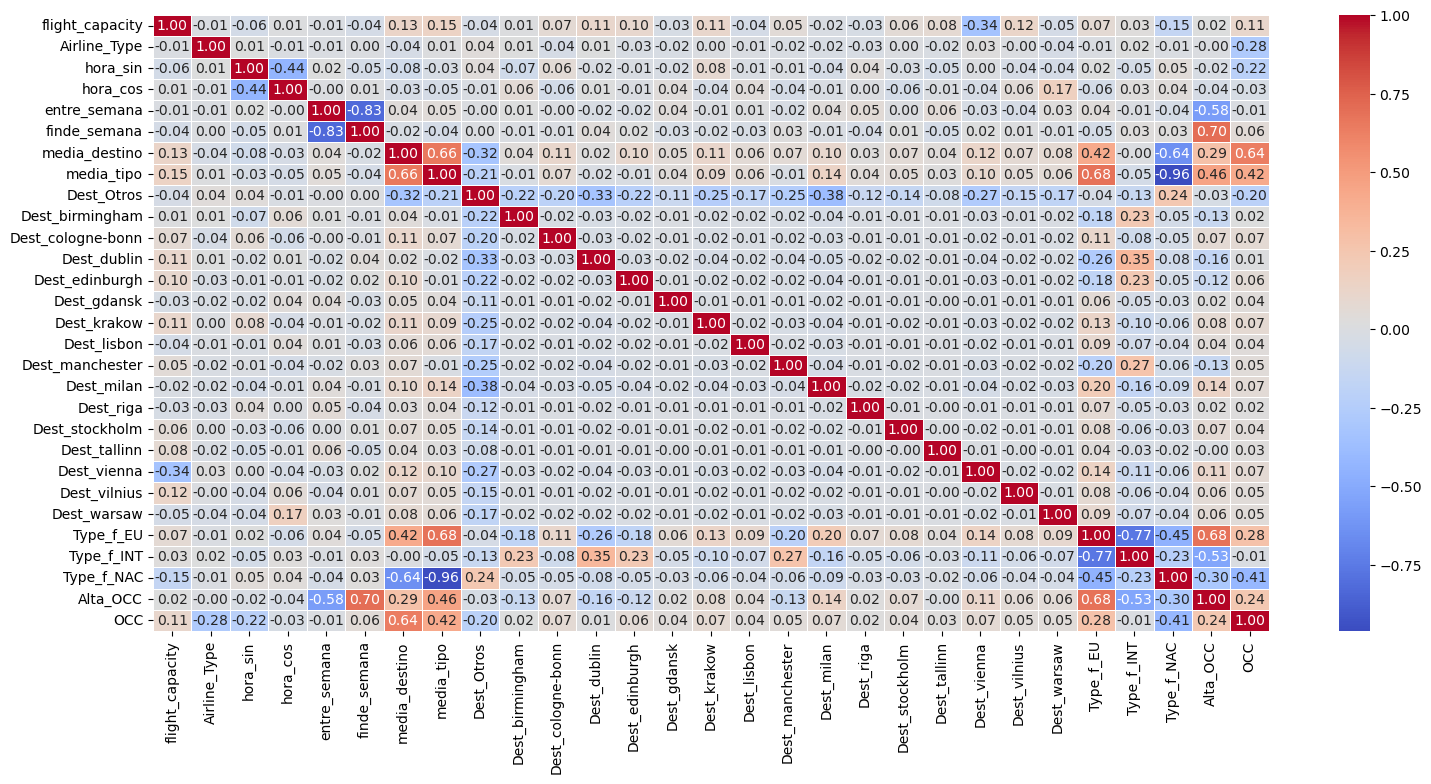

In [44]:
A = pd.concat([X_t, y], axis=1)

correlacion = A.corr()
plt.figure(figsize=(18,8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

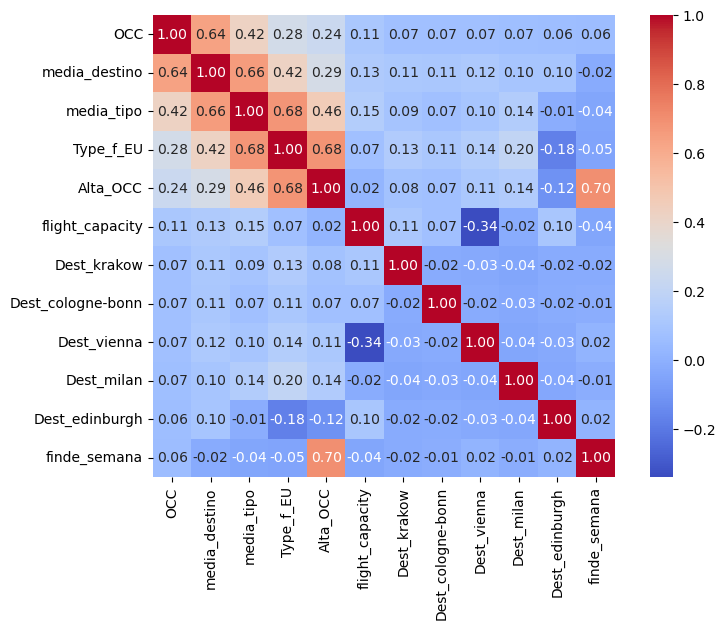

In [45]:
import numpy as np
import pandas as pd

k = 12 # número de variables
# 1. Obtener la lista de las 10 columnas más correlacionadas con 'OCC'
cols = correlacion.nlargest(k, 'OCC')['OCC'].index

# 2. SELECCIONAR el sub-DataFrame y CONVERTIRLO explícitamente a float para NumPy.
# Esto asegura que todos los datos sean float64 antes de calcular la transpuesta
matriz_datos = A[cols].astype(float).values.T

# 3. Calcular la matriz de correlación (ya no debería fallar)
cm = np.corrcoef(matriz_datos)

# 4. Visualización del heatmap
plt.figure(figsize=(9,6))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
            annot_kws={'size': 10},
            yticklabels=cols.values, 
            xticklabels=cols.values,
            cmap="coolwarm")
plt.show()

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size=0.20, random_state=42)

In [47]:
from sklearn.ensemble import RandomForestRegressor

rff = RandomForestRegressor(
    n_estimators=200,     # número de árboles
    max_depth=4,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=9,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rff.fit(X_train, y_train)
y_pred_test = rff.predict(X_test)
y_pred_train = rff.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print('RMSE Train:', rmse_rf_tr)
print('RMSE Test :', rmse_rf)
print('R2 Train  :', r2_rf_tr)
print('R2 Test   :', r2_rf)

RMSE Train: 0.060961559818697025
RMSE Test : 0.07015314575012017
R2 Train  : 0.6735441930431243
R2 Test   : 0.5560233980463996


In [48]:
# 1.1 Importancia de variables (RandomForest)
importance = pd.Series(rff.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance.head(30))


media_destino        0.602664
hora_sin             0.271298
Airline_Type         0.089324
hora_cos             0.022309
flight_capacity      0.002935
entre_semana         0.002707
Type_f_NAC           0.002686
Alta_OCC             0.002420
finde_semana         0.001345
Type_f_INT           0.001195
media_tipo           0.000763
Dest_Otros           0.000347
Type_f_EU            0.000007
Dest_stockholm       0.000000
Dest_warsaw          0.000000
Dest_vilnius         0.000000
Dest_vienna          0.000000
Dest_tallinn         0.000000
Dest_riga            0.000000
Dest_birmingham      0.000000
Dest_milan           0.000000
Dest_manchester      0.000000
Dest_lisbon          0.000000
Dest_gdansk          0.000000
Dest_edinburgh       0.000000
Dest_dublin          0.000000
Dest_cologne-bonn    0.000000
Dest_krakow          0.000000
dtype: float64


In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,     # número de árboles
    max_depth=3,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=9,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rf_tr)
print(rmse_rf)
print(r2_rf_tr)
print(r2_rf)

0.06329557212452129
0.07007246488019526
0.6480678713951391
0.5570440171543594


In [50]:
from sklearn.ensemble import RandomForestRegressor

rff = RandomForestRegressor(
    n_estimators=400,     # número de árboles
    max_depth=4,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=8,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rff.fit(X_train, y_train)
y_pred_test = rff.predict(X_test)
y_pred_train = rff.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rf_tr)
print(rmse_rf)
print(r2_rf_tr)
print(r2_rf)

0.05990954757910175
0.06967252967406688
0.6847142541867415
0.5620858875820492


In [51]:
from sklearn.ensemble import RandomForestRegressor

rff = RandomForestRegressor(
    n_estimators=1000,     # número de árboles
    max_depth=3,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=7,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rff.fit(X_train, y_train)
y_pred_test = rff.predict(X_test)
y_pred_train = rff.predict(X_train)

rmse_rff_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rff= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rff_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rff= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rff_tr)
print(rmse_rff)
print(r2_rff_tr)
print(r2_rff)

0.06189852281785164
0.06906486732983615
0.6634319965326843
0.5696912803865213


In [52]:
# 1.1 Importancia de variables (RandomForest)
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance.head(30))


media_destino        0.612461
hora_sin             0.276832
Airline_Type         0.094008
hora_cos             0.011747
Type_f_NAC           0.001525
entre_semana         0.001106
flight_capacity      0.000864
finde_semana         0.000785
media_tipo           0.000359
Alta_OCC             0.000313
Dest_cologne-bonn    0.000000
Dest_dublin          0.000000
Dest_Otros           0.000000
Type_f_INT           0.000000
Type_f_EU            0.000000
Dest_warsaw          0.000000
Dest_vilnius         0.000000
Dest_vienna          0.000000
Dest_tallinn         0.000000
Dest_stockholm       0.000000
Dest_riga            0.000000
Dest_milan           0.000000
Dest_manchester      0.000000
Dest_lisbon          0.000000
Dest_birmingham      0.000000
Dest_gdansk          0.000000
Dest_edinburgh       0.000000
Dest_krakow          0.000000
dtype: float64


In [53]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",        # o "gpu_hist" si tienes GPU
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# ===============================================================
# ESPACIO DE HIPERPARÁMETROS (puedes ajustarlo)
# ===============================================================
param_dist = {
    "n_estimators": [100, 200, 300], 
    
    # Profundidad baja para evitar memorizar datos
    "max_depth": [4, 5, 6],
    
    # Bajar esto es la mejor forma de combatir el overfitting en XGBoost
    "learning_rate": [ 0.005, 0.01, 0.02],
    
    # Submuestreo de filas y columnas más agresivo
    "subsample": [ 0.7, 0.8, 0.9], 
    "colsample_bytree": [0.6, 0.7, 0.8],
    
    # Mantener el peso de la hoja o ajustarlo
    "min_child_weight": [5, 6, 7, 8], 
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=200,                              # número de combinaciones a probar
    scoring="neg_root_mean_squared_error",  # RMSE (negativo por convención sklearn)
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# ===============================================================
# ENTRENAR EL MODELO FINAL CON LOS MEJORES PARÁMETROS
# ===============================================================
search.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(search.best_params_)
print("RMSE CV:", round(-search.best_score_, 4))

best_params = search.best_params_

xgb_final = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",      
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)
y_predt = xgb_final.predict(X_train)


# EVALUACIÓN FINAL EN TEST

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmset = np.sqrt(mean_squared_error(y_train, y_predt))
r2 = r2_score(y_test, y_pred)
r2t = r2_score(y_train, y_predt)

print("\n== XGBOOST (Optimizado) ==")
print("RMSE_test:", round(rmse, 4)) #medir performance real
print("RMSE_train:", round(rmset, 4)) #medir overfitting
print("R2_test:", round(r2, 4)) #medir performance real
print("R2_train:", round(r2t, 4)) #medir overfitting

#max_features-> seleccionar al azar la raiz de todas las var


Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Mejores hiperparámetros encontrados:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
RMSE CV: 0.0654

== XGBOOST (Optimizado) ==
RMSE_test: 0.0679
RMSE_train: 0.0551
R2_test: 0.5835
R2_train: 0.7333


{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 6, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
RMSE CV: 0.0623

== XGBOOST (Optimizado) ==
RMSE_test: 0.0554
RMSE_train: 0.0376
R2_test: 0.8205
R2_train: 0.9094

 Mejores hiperparámetros encontrados:
{'n_estimators': 90, 'max_depth': 8, 'learning_rate': 0.05}
RMSE CV: 0.0623

== XGBOOST (Optimizado) ==
RMSE_test: 0.0468
RMSE_train: 0.024
R2_test: 0.8718
R2_train: 0.9631

In [54]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

n_cv = 3
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
)

# ===============================================================
# ESPACIO DE HIPERPARÁMETROS (puedes ajustarlo)
# ===============================================================
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4,5, 6],
    "min_samples_leaf": [3, 5, 8],
    #"max_features": ["sqrt", 0.5],
    #"bootstrap": [True]
}
scoring = ['r2']



# creamos la GridSeacrh
grid_solver = GridSearchCV(estimator = rf, # model to train RandomForestRegressor() 
                           param_grid = params, # param_grid
                           scoring = scoring,
                           cv = n_cv, # 3
                           refit = 'r2', # la metrica que va a usar para decidir el mejor modelo
                           verbose = 3) 

# ===============================================================
# ENTRENAR EL MODELO FINAL CON LOS MEJORES PARÁMETROS
# ===============================================================
grid_solver.fit(X_train, y_train)

best_params = grid_solver.best_params_ # <--- ¡CORRECCIÓN! Usar best_params_
print("\nMejores parámetros encontrados:")
print(best_params)

rf_final = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params
)

rf_final.fit(X_train, y_train)
y_pred = rf_final.predict(X_test)
y_predt = rf_final.predict(X_train)


# EVALUACIÓN FINAL EN TEST

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmset = np.sqrt(mean_squared_error(y_train, y_predt))
r2 = r2_score(y_test, y_pred)
r2t = r2_score(y_train, y_predt)

print("\n== RANDOM-FOREST (Optimizado) ==")
print("RMSE_test:", round(rmse, 4)) #medir performance real
print("RMSE_train:", round(rmset, 4)) #medir overfitting
print("R2_test:", round(r2, 4)) #medir performance real
print("R2_train:", round(r2t, 4)) #medir overfitting

#max_features-> seleccionar al azar la raiz de todas las var


Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV 1/3] END max_depth=None, min_samples_leaf=3, n_estimators=100; r2: (test=0.645) total time=   0.1s
[CV 2/3] END max_depth=None, min_samples_leaf=3, n_estimators=100; r2: (test=0.556) total time=   0.1s
[CV 3/3] END max_depth=None, min_samples_leaf=3, n_estimators=100; r2: (test=0.640) total time=   0.1s
[CV 1/3] END max_depth=None, min_samples_leaf=3, n_estimators=200; r2: (test=0.648) total time=   0.2s
[CV 2/3] END max_depth=None, min_samples_leaf=3, n_estimators=200; r2: (test=0.554) total time=   0.2s
[CV 3/3] END max_depth=None, min_samples_leaf=3, n_estimators=200; r2: (test=0.642) total time=   0.2s
[CV 1/3] END max_depth=None, min_samples_leaf=3, n_estimators=300; r2: (test=0.648) total time=   0.3s
[CV 2/3] END max_depth=None, min_samples_leaf=3, n_estimators=300; r2: (test=0.553) total time=   0.4s
[CV 3/3] END max_depth=None, min_samples_leaf=3, n_estimators=300; r2: (test=0.644) total time=   0.4s
[CV 1/3] EN

In [55]:
# 1.1 Importancia de variables (RandomForest)
importances = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(30))


media_destino        5.574767e-01
hora_sin             2.896675e-01
Airline_Type         7.973165e-02
hora_cos             4.254656e-02
flight_capacity      7.592222e-03
entre_semana         5.069677e-03
finde_semana         4.365857e-03
Alta_OCC             3.020606e-03
Dest_Otros           2.989330e-03
Type_f_NAC           2.591137e-03
Type_f_INT           2.269797e-03
media_tipo           2.136533e-03
Type_f_EU            2.868459e-04
Dest_milan           9.765982e-05
Dest_lisbon          7.772434e-05
Dest_manchester      5.403515e-05
Dest_dublin          8.867096e-06
Dest_edinburgh       8.851698e-06
Dest_birmingham      4.955518e-06
Dest_warsaw          1.552253e-06
Dest_riga            1.038868e-06
Dest_krakow          3.537841e-07
Dest_cologne-bonn    2.951350e-07
Dest_vienna          1.680913e-07
Dest_vilnius         0.000000e+00
Dest_tallinn         0.000000e+00
Dest_stockholm       0.000000e+00
Dest_gdansk          0.000000e+00
dtype: float64


'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 8, 'max_depth': 11, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
RMSE CV: 0.0575

== XGBOOST (Optimizado) ==
RMSE_test: 0.0682
RMSE_train: 0.0442
R2_test: 0.73
R2_train: 0.8536

In [56]:
modelo_entero= rff.fit(X_t,y) 

In [57]:
x = df_gr

In [58]:
X_f, encoder, label_encoders, top_destinos = transforma_datos(x,
    encoder=encoder,
    label_encoders=label_encoders,
    top_destinos=top_destinos,                                       
    media_destino_map=media_destino_map,
    global_media=global_media,
    ajustar_encoders=False) # NO AJUSTAR SOLO TRANSFORMAR CON LO AJUSTADO  
                                                              
y_hat = rff.predict(X_f)

C:\Users\linap\AppData\Local\Temp\ipykernel_27020\1911919217.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Airline_Type"] = X["Airline_Type"].replace({"Low_Cost": 0, "Legacy": 1})


In [59]:
y_hat

array([0.94562073, 0.9661215 , 0.9457133 , ..., 0.95076695, 0.94681619,
       0.96347034])

In [60]:
X_f

,flight_capacity,Airline_Type,hora_sin,hora_cos,entre_semana,finde_semana,media_destino,media_tipo,Dest_Otros,Dest_birmingham,...,Dest_riga,Dest_stockholm,Dest_tallinn,Dest_vienna,Dest_vilnius,Dest_warsaw,Type_f_EU,Type_f_INT,Type_f_NAC,Alta_OCC
2,156,0,0.997859,-0.065403,1,0,0.93,0.93,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
6,156,0,0.980785,-0.195090,1,0,0.95,0.93,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
9,156,0,0.939693,-0.342020,1,0,0.93,0.93,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
10,156,0,0.939693,-0.342020,1,0,0.96,0.93,False,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
14,189,0,0.866025,-0.500000,1,0,0.95,0.93,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,180,0,-0.537300,0.843391,0,1,0.92,0.93,True,False,...,False,False,False,False,False,False,0.0,1.0,0.0,1.0
2698,180,0,-0.518773,0.854912,0,1,0.93,0.93,True,False,...,False,False,False,False,False,False,1.0,0.0,0.0,2.0
2699,239,0,-0.518773,0.854912,0,1,0.93,0.93,True,False,...,False,False,False,False,False,False,0.0,1.0,0.0,1.0
2700,230,0,-0.321439,0.946930,0,1,0.93,0.93,True,False,...,False,False,False,False,False,False,0.0,1.0,0.0,1.0


In [61]:
df_gr['OCC'] = y_hat.round(2)

In [62]:
df_gr

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest,Airline_Type,OCC
2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost,0.95
6,2025-11-17,Grupo easy,EC8062,london,06:45:00,Retrasado,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost,0.97
9,2025-11-17,Grupo easy,EC7141,strasbourg,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost,0.95
10,2025-11-17,Grupo easy,EC7151,milan,07:20:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0,Low_Cost,0.97
14,2025-11-17,Norwegian Air Sweden AOC,D85510,copenhagen,08:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0,Low_Cost,0.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2697,2025-12-07,Grupo easy,U22706,bristol,21:50:00,En hora,180,Airbus A320,M,INT,Domingo,Noche,0,1,Low_Cost,0.93
2698,2025-12-07,Volotea,V71415,verona,21:55:00,En hora,180,Airbus A320,R,EU,Domingo,Noche,0,1,Low_Cost,0.95
2699,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1,Low_Cost,0.95
2700,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1,Low_Cost,0.95


In [63]:
df_gr[(df_gr['Airline_Type'] == 'Legacy')]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest,Airline_Type,OCC
34,2025-11-17,Air Serbia,JU581,belgrade,09:55:00,En hora,144,Airbus A319,W,INT,Lunes,Mañana,0,0,Legacy,0.86
75,2025-11-17,Luxair,LG3592,luxembourg,13:35:00,Retrasado,76,de Havilland Dash 8-400,U,EU,Lunes,Tarde,0,0,Legacy,0.86
78,2025-11-17,Turkish Airlines,TK608,ankara,13:40:00,Retrasado,165,Boeing 737-800,Y,INT,Lunes,Tarde,0,0,Legacy,0.86
143,2025-11-17,Air Serbia,JU585,belgrade,20:35:00,En hora,144,Airbus A319,W,INT,Lunes,Noche,0,0,Legacy,0.86
190,2025-11-18,Air Serbia,JU581,belgrade,09:55:00,En hora,144,Airbus A319,Y,INT,Martes,Mañana,0,0,Legacy,0.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2476,2025-12-06,Kuwait Airways,KU136,kuwait city,14:25:00,En hora,235,Airbus A330-800,W,INT,Sábado,Tarde,1,0,Legacy,0.86
2480,2025-12-06,Turkish Airlines,TK608,ankara,14:50:00,En hora,151,Boeing 737 MAX 8,W,INT,Sábado,Tarde,1,0,Legacy,0.86
2589,2025-12-07,Icelandair,FI597,keflavik,11:50:00,Retrasado,160,Boeing 737 MAX 8,U,EU,Domingo,Mañana,0,1,Legacy,0.86
2675,2025-12-07,Air Serbia,JU585,belgrade,20:35:00,En hora,174,Airbus A320,Y,INT,Domingo,Noche,0,1,Legacy,0.86


In [64]:
# Definir la condición 
es_turkish = (df_gr['Name_company'] == 'Turkish Airlines')

# 2. Usar la condición para filtrar y calcular la media de OCC
media_turkish = df_gr.loc[es_turkish, "OCC"].mean().round(2)

# 3. Imprimir el resultado
print(f"Media de Ocupación (Turkish Airlines): {media_turkish}")

Media de Ocupación (Turkish Airlines): 0.86


In [68]:
df_gr.to_csv("Tabla_vuelos_otos_occ2.csv") 

In [66]:
df_pk

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC,Name_company,Airline_Type
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0,0,0.93,Grupo Ryanair,Low_Cost
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0,0,0.95,Grupo Ryanair,Low_Cost
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0,0,0.98,Grupo Ryanair,Low_Cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,1,0.94,Grupo Ryanair,Low_Cost
1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,1,1.00,Grupo Ryanair,Low_Cost
1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,1,0.94,Grupo Ryanair,Low_Cost
1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,1,1.00,Grupo Ryanair,Low_Cost


In [69]:
df_pk.to_csv("Tabla_ryr2.csv") 